In [31]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

In [32]:
#read in raw data and make stationary
cpc = pd.read_csv('search_cpc.csv', parse_dates=['date'], index_col='date')
cpc_diff = cpc.diff()
cpc_diff = cpc_diff.dropna()

# Question 1

Plot the ACF and PACF of cpc_diff. Based on the plots, can the model order be deduced? If yes, what is the model order?

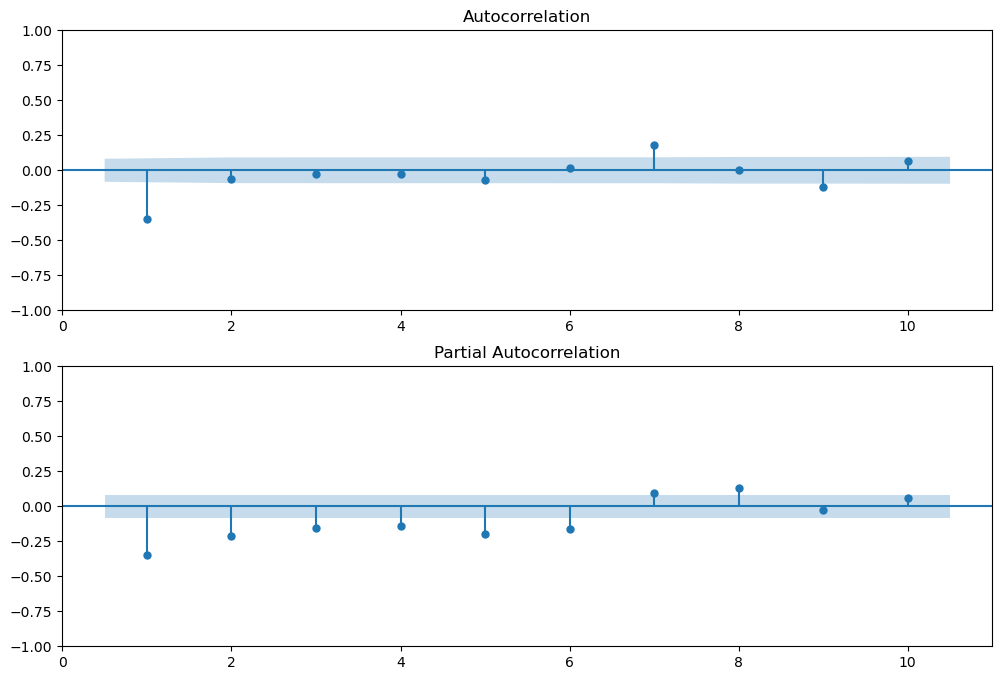

In [3]:
# Create figure
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
 
# Plot the ACF of df
plot_acf(cpc_diff, lags=10, zero=False, ax=ax1)

# Plot the PACF of df
plot_pacf(cpc_diff, lags=10, zero=False, ax=ax2)

plt.show()

MA(1) from a glance, but could also fit the definition of ARMA

# Question 2

Write a for loop to loop over orders between 0 and 3 for p and q. Within the loop, try to fit an ARMA(p,q) and create an exception to print instances where the model fitting procedure fails. What is the model order for the best predictive model? 

In [4]:
#Loop over p values from 0-3
for p in range(4):
    #Loop over q values from 0-3
    for q in range(4):
      
        try:
            #create and fit ARMA(p,q) model
            model = ARIMA(cpc_diff, order=(p,0,q))
            results = model.fit()
            
            #Print order and results
            print(p, q, results.aic, results.bic)
            
        except:
            print(p, q, None, None)

0 0 3202.6128237145704 3211.2900118709767
0 1 3079.471976232652 3092.4877584672618
0 2 3069.2592210783405 3086.6135973911532
0 3 3069.7857084312004 3091.4786788222164
1 0 3131.0835251987937 3144.0993074334033
1 1 3067.9835862435098 3085.3379625563225
1 2 3069.9383696433097 3091.6313400343256
1 3 3071.737820066406 3097.7693845356252
2 0 3106.9948201843767 3124.3491964971895
2 1 3069.9233439878694 3091.6163143788854
2 2 3071.8527683467782 3097.8843328159974
2 3 3039.4366598897063 3069.8068184371286
3 0 3095.0555160501303 3116.7484864411463
3 1 3071.421254841369 3097.452819310588
3 2 3059.3877359532516 3089.757894500674
3 3 3075.8341958987785 3110.542948524404


ARMA[2,3]

# Question 3

Fit a model based off the best predictive model from Question 2 and create the four diagnostic plots. Which of the four plots indicate that there's room for model improvement?

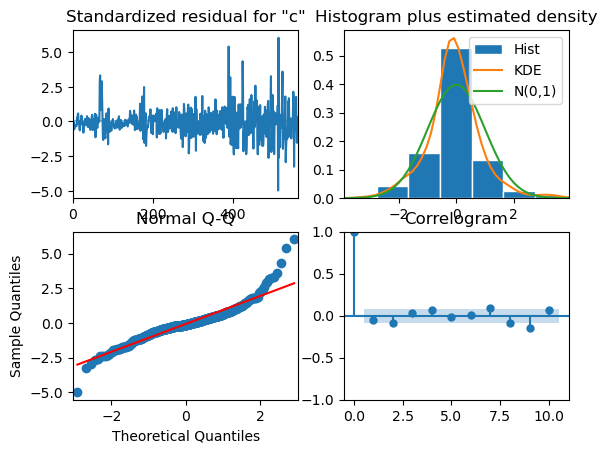

In [5]:
#create and fit model
model = ARIMA(cpc_diff, order=(2,0,3))
results = model.fit()

#create the 4 diagnostics plots
results.plot_diagnostics()
plt.show()

Standardized residual plot indicates that there may be a trend, and Q-Q plot shows that residuals in the upper quantiles are not exactly normally distributed

# Question 4

We know from the augmented Dickey-Fuller test in Part 1, as well as the seasonal decomposition below that our time series has a trend and is non-stationary. Subtract a 365 step rolling mean from the time series and assign to a variable named cpc_2. Then plot the ACF with a time lag of 30 steps and show the plot. What is the time period of the seasonal component of this data?

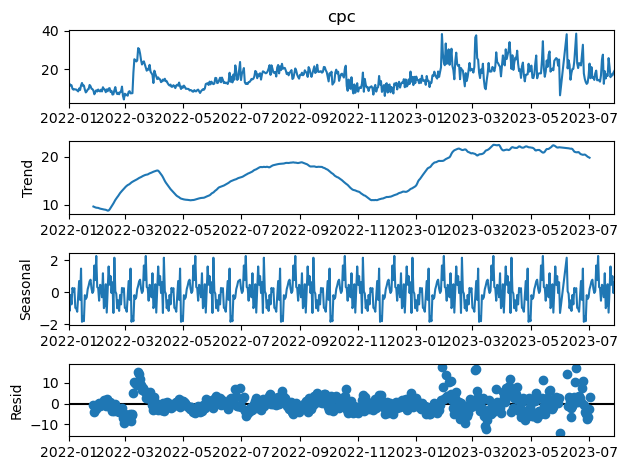

In [21]:
cpc = pd.read_csv('search_cpc.csv', parse_dates=['date'], index_col='date')

decomp = seasonal_decompose(cpc['cpc'], period=52)
decomp.plot()
plt.show()

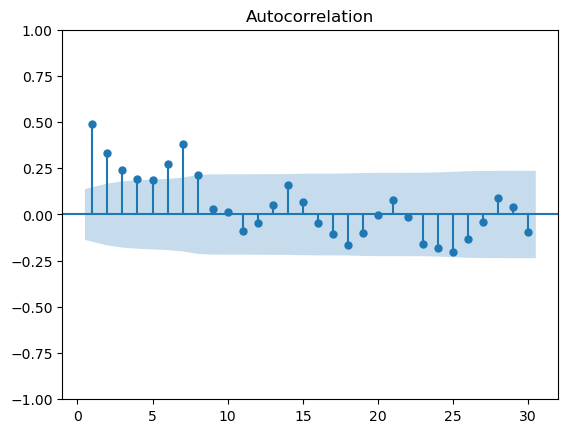

In [13]:
#subtract the rolling mean
cpc_2 = cpc - cpc.rolling(365).mean()

#drop the NaN values
cpc_2 = cpc_2.dropna()

#create figure and subplots
fig, ax1 = plt.subplots()

#plot the ACF
plot_acf(cpc_2['cpc'], lags=30, zero=False, ax=ax1)

#show figure
plt.show()

7 time steps or weekly seasonality since our data is daily

# Question 5

Take the first order and seasonal difference from cpc and drop NAs and name your variable cpc_diff_season. Then plot the ACF and PACF up to 11 lags and interpret the non-seasonal model order from the plots. Then plot the seasonal ACF and PACF plots for the first 5 seasonal lags.

The guideline for interpreting model order is in the cell below, and can be used for both non-seasonal and seasonal ACF and PACF plots. 

What model is most likely for this data?

Hints:
1. You can chain the diff() function together to take the first order and seasonal difference in one line of code
2. The seasonal time lag is 7 time steps
3. Make sure to pass in time lags as a list for the seasonal ACF and PACF plots
4. Feel free to use multiple cells for this question

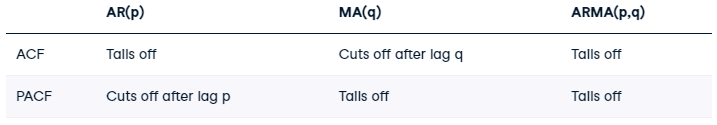

In [14]:
cpc_diff_season = cpc.diff().diff(7).dropna()

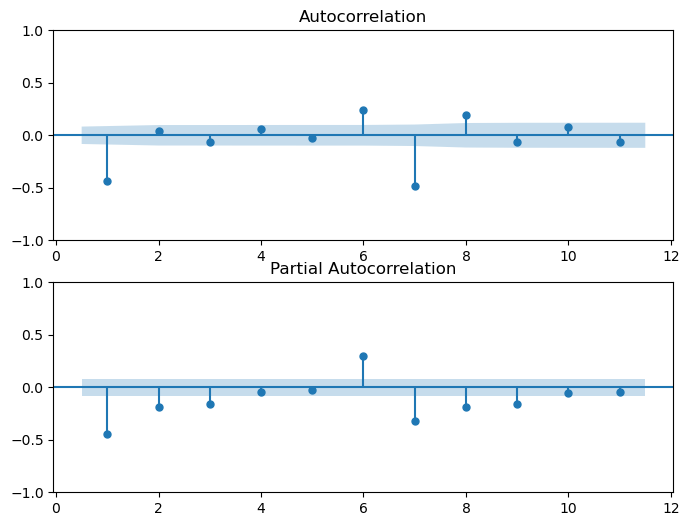

In [15]:
#create the figure 
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(8,6))

#plot the ACF on ax1
plot_acf(cpc_diff_season, lags=11, zero=False, ax=ax1)

#plot the PACF on ax2
plot_pacf(cpc_diff_season, lags=11, zero=False, ax=ax2)

plt.show() #normal MA(1)

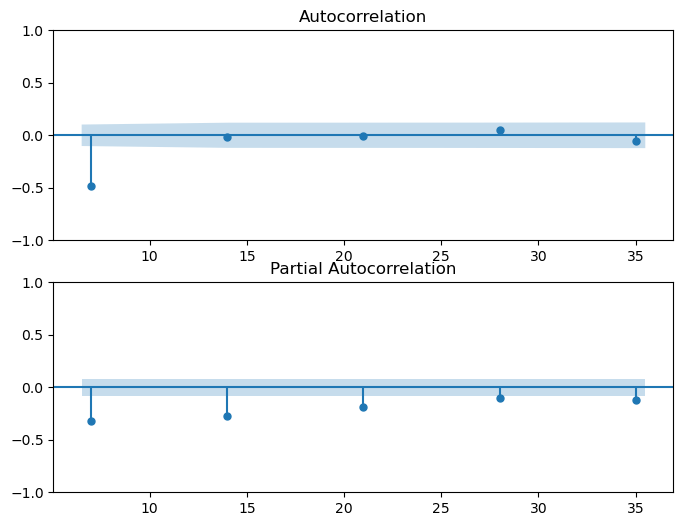

In [16]:
#make list of lags
lags = [7, 14, 21, 28, 35]

#create the figure 
fig, (ax1, ax2) = plt.subplots(2,1,figsize=(8,6))

#plot the ACF on ax1
plot_acf(cpc_diff_season, lags=lags, ax=ax1)

#plot the PACF on ax2
plot_pacf(cpc_diff_season, lags=lags, ax=ax2)

plt.show() #seasonal MA(1)

SARIMAX(0,1,1)(0,1,1)$_{7}$

In [33]:
#create model object and fit the model
model = SARIMAX(cpc, order=(0,1,1), seasonal_order=(0,1,1,7))
results = model.fit()

#create forecast object for 91 steps into the future
forecast_object = results.get_forecast(steps=91)

#extract prediction mean
mean = forecast_object.predicted_mean

#extract the confidence intervals
conf_int = forecast_object.conf_int()

# extract the forecast dates
dates = mean.index

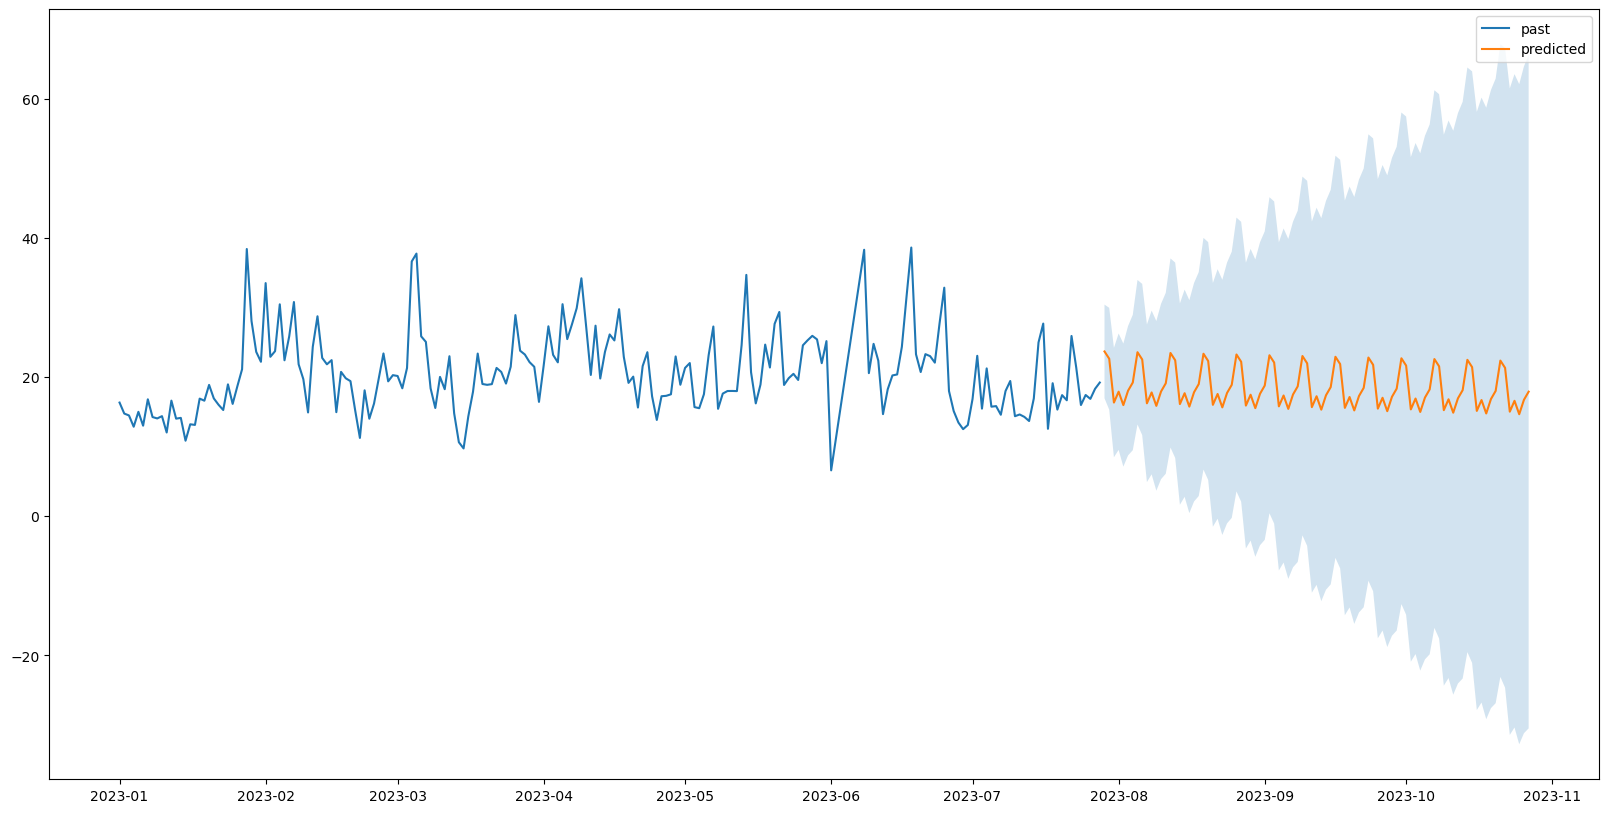

In [37]:
import matplotlib.dates as mdates

forecast_dates = pd.date_range(start=cpc.index[-1] + pd.Timedelta(days=1), periods=91, freq='D')
forecast_series = pd.Series(mean.values, index=forecast_dates)

plt.figure(figsize=(20,10))

#plot past paid search CPCs
cpc_short = cpc["2023-01-01": "2023-07-28"]
plt.plot(cpc_short.index, cpc_short, label='past')

#plot the prediction means as line
plt.plot(forecast_series.index, forecast_series, label='predicted')

#shade between the confidence intervals
plt.fill_between(forecast_series.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)

#plot legend and show figure
plt.legend()
plt.show()